# EDA: creditcard.csv

Exploratory Data Analysis for the bank credit card transaction dataset.
Covers:
1. Load & shape inspection
2. Missing values & duplicates
3. Class imbalance quantification
4. Distributions of Amount, Time, and PCA features
5. Bivariate analysis

In [1]:
# ── 1. Imports ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_palette('Set2')
print("Imports OK")

Imports OK


In [5]:
# ── 2. Load data ───────────────────────────────────────────────────────────────
cc = pd.read_csv('../data/raw/creditcard (3).csv')
print(f"Shape: {cc.shape[0]:,} rows × {cc.shape[1]} cols")
cc.head(3)


Shape: 284,807 rows × 31 cols


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [6]:
# ── 3. Data cleaning ──────────────────────────────────────────────────────────
# Missing values
print("Missing values:\n", cc.isnull().sum().to_string())

# Duplicates
dupes = cc.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
cc = cc.drop_duplicates()
print(f"Shape after removing duplicates: {cc.shape}")

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0

Duplicate rows: 1081
Shape after removing duplicates: (283726, 31)


Legitimate (0): 283,253  (99.83%)
Fraud      (1): 473  (0.17%)


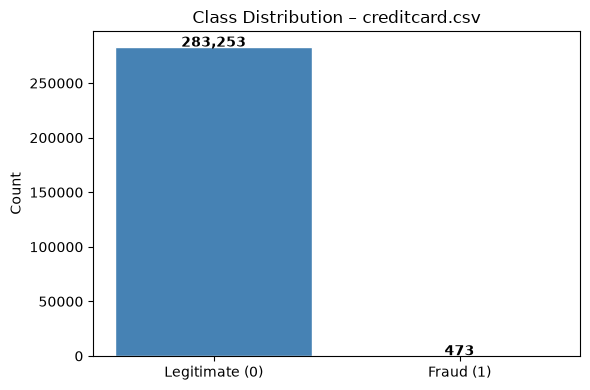

In [7]:
# ── 4. Class imbalance ────────────────────────────────────────────────────────
counts   = cc['Class'].value_counts()
fraud_pct = counts[1] / len(cc) * 100

print(f"Legitimate (0): {counts[0]:,}  ({100-fraud_pct:.2f}%)")
print(f"Fraud      (1): {counts[1]:,}  ({fraud_pct:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
       color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Class Distribution – creditcard.csv')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/cc_class_imbalance.png', dpi=100)
plt.show()

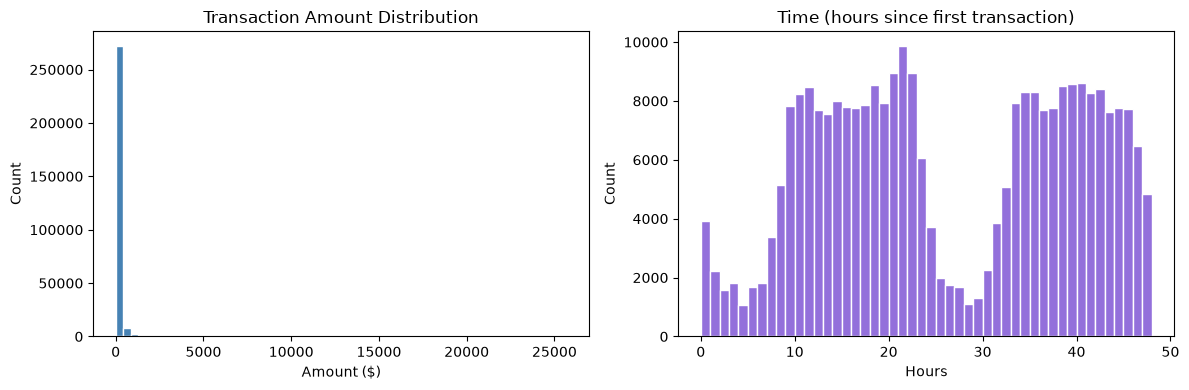

In [8]:
# ── 5a. Distribution of Amount & Time ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cc['Amount'], bins=60, edgecolor='white', color='steelblue')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')

axes[1].hist(cc['Time'] / 3600, bins=48, edgecolor='white', color='mediumpurple')
axes[1].set_title('Time (hours since first transaction)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/cc_amount_time_dist.png', dpi=100)
plt.show()


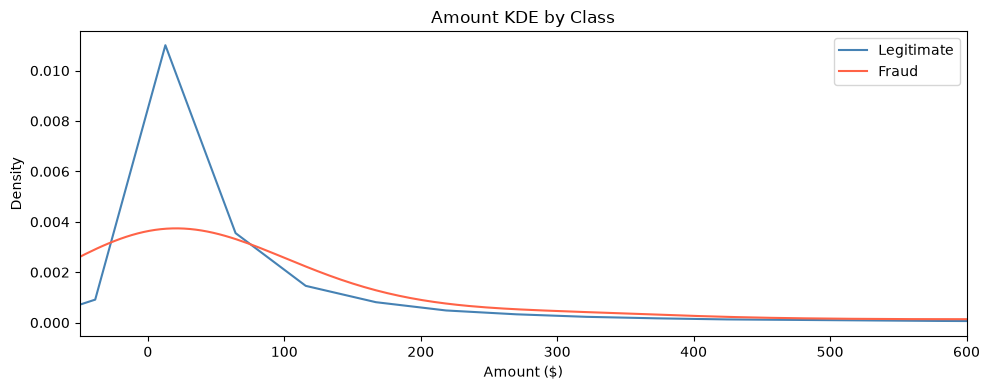

Median Amount — Legitimate: 22.0
Median Amount — Fraud     : 9.82


In [9]:
# ── 5b. Amount distribution by class ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for cls, label, color in [(0,'Legitimate','steelblue'), (1,'Fraud','tomato')]:
    cc[cc['Class'] == cls]['Amount'].plot(
        kind='kde', ax=ax, label=label, color=color)
ax.set_title('Amount KDE by Class')
ax.set_xlabel('Amount ($)')
ax.legend()
ax.set_xlim(-50, 600)
plt.tight_layout()
plt.savefig('../data/processed/cc_amount_by_class.png', dpi=100)
plt.show()

print("Median Amount — Legitimate:", cc[cc['Class']==0]['Amount'].median())
print("Median Amount — Fraud     :", cc[cc['Class']==1]['Amount'].median())

Top-10 V-features correlated with Class:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340


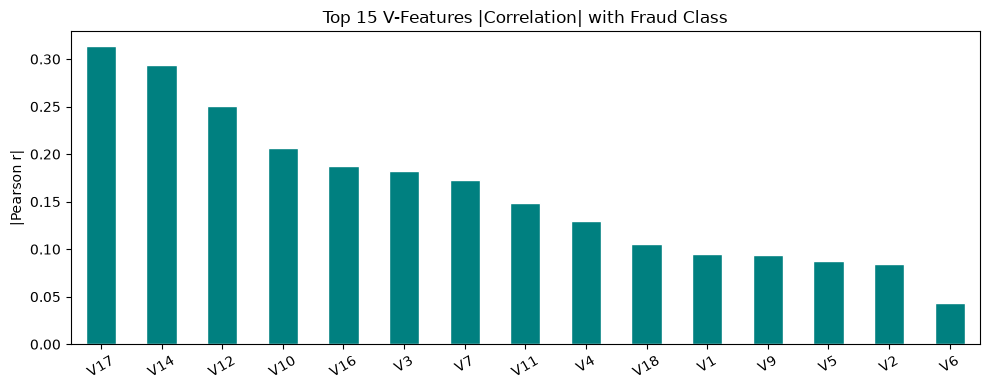

In [10]:
# ── 5c. Top PCA feature correlations with Class ───────────────────────────────
# Identify which V-features have the strongest correlation with Class
v_cols = [f'V{i}' for i in range(1, 29)]
corrs  = cc[v_cols + ['Class']].corr()['Class'].drop('Class').abs().sort_values(ascending=False)

print("Top-10 V-features correlated with Class:")
print(corrs.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
corrs.head(15).plot(kind='bar', ax=ax, edgecolor='white', color='teal')
ax.set_title('Top 15 V-Features |Correlation| with Fraud Class')
ax.set_ylabel('|Pearson r|')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/cc_feature_corr.png', dpi=100)
plt.show()

In [11]:
# ── 6. Save cleaned creditcard data ──────────────────────────────────────────
cc.to_csv('../data/processed/creditcard_clean.csv', index=False)
print("Saved: data/processed/creditcard_clean.csv")


Saved: data/processed/creditcard_clean.csv
